## Merging the Stoke UPRNs in a cluster into one polygon

This will be better for the viz than keeping them as points coloured by cluster number.

In [1]:
import pandas as pd
import geopandas as gpd
from shapely.ops import unary_union
import matplotlib.pyplot as plt

import os
import random

from asf_heat_pump_suitability import PROJECT_DIR

## Read data

In [2]:
# Locally saved, eventually this will be on S3
output_directory = os.path.join(PROJECT_DIR, "outputs/area_specific_analysis/stoke/")

building_footprints = gpd.read_file(os.path.join(output_directory, 'buildings.geojson')).to_crs(epsg=4326)
UPRNs_clustered = gpd.read_file(os.path.join(output_directory, 'uprns_with_suitability.geojson')).to_crs(epsg=4326)

## Process and join data

Find which building polygons each UPRN point sits within (if any)

In [3]:
UPRNs_clustered = gpd.GeoDataFrame(
    UPRNs_clustered, geometry=gpd.points_from_xy(
        UPRNs_clustered.LONGITUDE,
        UPRNs_clustered.LATITUDE
    ), crs="EPSG:4326"
)

In [4]:
building_footprints['building_geom'] = building_footprints.geometry # Otherwise there are 2 geometry columns and this one gets dropped in the join

In [5]:
UPRNs_joined_buildings = gpd.sjoin(UPRNs_clustered, building_footprints, how="inner", predicate="intersects", )

Finding out a few stats about this join

In [6]:
print(len(building_footprints))
print(len(UPRNs_clustered))
print(len(UPRNs_joined_buildings))

1609
21494
18833


In [7]:
print(f"{UPRNs_joined_buildings['UPRN'].nunique()} out of {UPRNs_clustered['UPRN'].nunique()} unique UPRNs were found within building polygons. ")

18833 out of 21494 unique UPRNs were found within building polygons. 


In [8]:
a = set(UPRNs_joined_buildings['cluster'].unique())
b = set(UPRNs_clustered['cluster'].unique())
print(f"{len(b.difference(a))} clusters out of {UPRNs_clustered['cluster'].nunique()} did not have at least one building polygon associated with it")

14 clusters out of 550 did not have at least one building polygon associated with it


## Merge building footprints
For every cluster, find the union of the building polygons the UPRNs sit in

In [9]:
def merge_polygons(polygon_list):
    merged_polygon = gpd.GeoSeries(unary_union(polygon_list))
    return merged_polygon

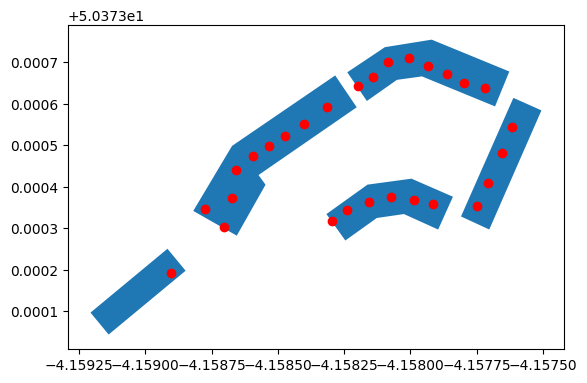

In [10]:
# Example
# There will still be gaps between the geometries

cluster_number = 102
UPRNs_joined_buildings_filtered = UPRNs_joined_buildings[UPRNs_joined_buildings['cluster']==cluster_number]

fig, ax = plt.subplots(1, 1)
gpd.GeoSeries(unary_union(UPRNs_joined_buildings_filtered['building_geom'])).plot(ax=ax)
UPRNs_joined_buildings_filtered[['geometry']].plot(ax=ax, color='red')
plt.show()

- Merge polygons for clusters
- Merge the merged polygons to the UPRN data

In [11]:
merged_polygons_per_cluster = UPRNs_joined_buildings.groupby('cluster')['building_geom'].apply(lambda x: merge_polygons(x)).reset_index()

In [12]:
UPRNs_clustered_final = UPRNs_clustered.merge(merged_polygons_per_cluster, on='cluster', how="left")

#### Some stats

In [13]:
# Set a label to show that a UPRN has a building polygon
UPRNs_clustered_final['UPRN_joined_to_a_building_polygon'] = UPRNs_clustered_final['UPRN'].apply(lambda x: x in UPRNs_joined_buildings['UPRN'].tolist())

In [14]:
UPRNs_clustered_final['UPRN_joined_to_a_building_polygon'].value_counts()

UPRN_joined_to_a_building_polygon
True     18833
False     2661
Name: count, dtype: int64

In [15]:
# Set a label to see if the cluster this UPRN is in has a polygon
UPRNs_clustered_final["cluster_polygon_found"] = UPRNs_clustered_final['building_geom'].notnull()

In [16]:
UPRNs_clustered_final["cluster_polygon_found"].value_counts()

cluster_polygon_found
True     21337
False      157
Name: count, dtype: int64

In [17]:
def get_type(cluster, UPRN_joined_to_a_building_polygon, cluster_polygon_found):
    if cluster==-1:
        return "Not clustered"
    elif cluster_polygon_found:
        if UPRN_joined_to_a_building_polygon:
            return "UPRN and cluster in polygon"
        else:
            return "UPRN not in a polygon, but others in cluster are"
    else:
        if UPRN_joined_to_a_building_polygon:
            return "Unsual" # Shouldnt happen
        else:
            return "UPRN nor any others in cluster are in any polygons"

In [18]:
# Set a single label to combine the different cases for this UPRN being in a polygon
UPRNs_clustered_final['Type'] = UPRNs_clustered_final.apply(lambda x: get_type(
    x['cluster'], x['UPRN_joined_to_a_building_polygon'], x['cluster_polygon_found']
), axis=1)

In [19]:
UPRNs_clustered_final['Type'].value_counts()

Type
UPRN and cluster in polygon                           17886
UPRN not in a polygon, but others in cluster are       2079
Not clustered                                          1372
UPRN nor any others in cluster are in any polygons      157
Name: count, dtype: int64

In [20]:
UPRNs_clustered_final['Type'].value_counts(normalize=True)

Type
UPRN and cluster in polygon                           0.832139
UPRN not in a polygon, but others in cluster are      0.096725
Not clustered                                         0.063832
UPRN nor any others in cluster are in any polygons    0.007304
Name: proportion, dtype: float64

### Save data
#### Per UPRN which cluster and the extra info about whether it was in a polygon


In [21]:
UPRNs_clustered_final.drop(columns=['building_geom', 'geometry']).to_csv(
    os.path.join(output_directory, "per_uprn_merged_polygons.csv"),
)

#### Per building footprint
All polygons for Stoke, and information about whether UPRNs were in it

In [22]:
# Get the building polygons with no UPRNs in
building_footprints_no_uprn = building_footprints[~building_footprints['building_geom'].isin(UPRNs_joined_buildings['building_geom'])]

In [23]:
# The polygons per cluster + the polygons with no UPRNs
all_building_polygons = pd.concat([merged_polygons_per_cluster, building_footprints_no_uprn[['building_geom']]])

/Users/elizabethgallagher/miniconda3/envs/asf_heat_pump_suitability/lib/python3.10/site-packages/geopandas/array.py:1638: UserWarning: CRS not set for some of the concatenation inputs. Setting output's CRS as WGS 84 (the single non-null crs provided).
  return GeometryArray(data, crs=_get_common_crs(to_concat))


In [24]:
# A label about which type of polygon it is (in terms of UPRN clusters within it)
all_building_polygons['Type'] = all_building_polygons['cluster'].apply(
    lambda x: 'Has UPRNS but no cluster' if x==-1 else ('No UPRN' if pd.isnull(x) else 'Has UPRN from a cluster')
)

In [25]:
gpd.GeoDataFrame(all_building_polygons, geometry="building_geom").to_file(
    os.path.join(output_directory, "per_cluster_merged_polygons_inc_no_uprns.geojson"),
    driver="GeoJSON"
)

2025-08-21 10:54:22,077 - pyogrio._io - INFO - Created 604 records


#### Some stats

In [27]:
print(len(merged_polygons_per_cluster))
print(len(building_footprints_no_uprn))

536
68


In [28]:
all_building_polygons['Type'].value_counts()

Type
Has UPRN from a cluster     535
No UPRN                      68
Has UPRNS but no cluster      1
Name: count, dtype: int64

## Testing: Some clusters have overlapped with the same building polygon as others

This section is just checking things about the data, no saving is done

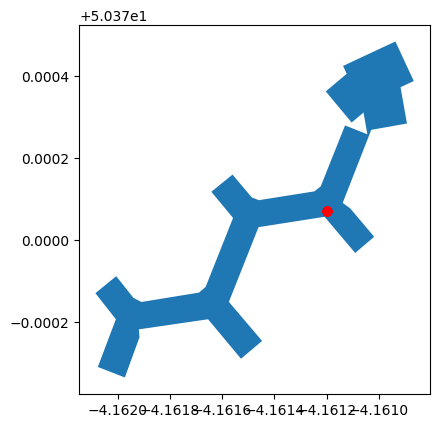

In [29]:
cluster_number = 200
joined_filtered = UPRNs_joined_buildings[UPRNs_joined_buildings['cluster']==cluster_number]

fig, ax = plt.subplots(1, 1)
gpd.GeoSeries(unary_union(joined_filtered['building_geom'])).plot(ax=ax)
joined_filtered[['geometry']].plot(ax=ax, color='red')
plt.show()

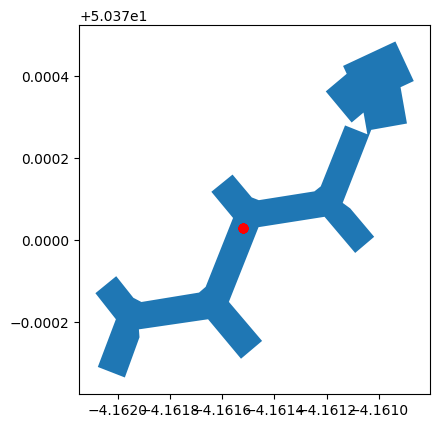

In [30]:
cluster_number = 205
joined_filtered = UPRNs_joined_buildings[UPRNs_joined_buildings['cluster']==cluster_number]

fig, ax = plt.subplots(1, 1)
gpd.GeoSeries(unary_union(joined_filtered['building_geom'])).plot(ax=ax)
joined_filtered[['geometry']].plot(ax=ax, color='red')
plt.show()

How often does this happen?

In [34]:
buildings_with_clusters = all_building_polygons[all_building_polygons['Type']=='Has UPRN from a cluster']

In [35]:
print(f"There are {buildings_with_clusters['building_geom'].nunique()} unique cluster polygons for {len(buildings_with_clusters)} clusters")

There are 514 unique cluster polygons for 535 clusters


In [36]:
duplicated_cluster_polygons = buildings_with_clusters[buildings_with_clusters.duplicated(subset="building_geom", keep=False)]

In [37]:
print(f"There are {len(duplicated_cluster_polygons)} clusters in the same {duplicated_cluster_polygons['building_geom'].nunique()} polygons")

There are 35 clusters in the same 14 polygons


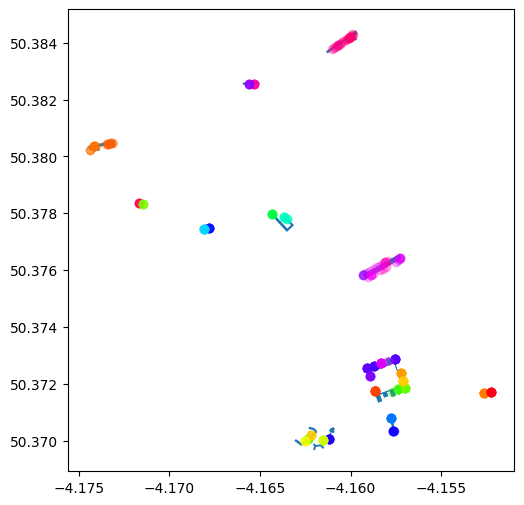

In [40]:
clusters_in_dupes = duplicated_cluster_polygons.groupby('building_geom')['cluster'].unique().reset_index()

cmap = plt.cm.get_cmap('hsv', 500)
    
fig, ax = plt.subplots(1, 1, figsize=(10,6))

gpd.GeoSeries(clusters_in_dupes['building_geom']).plot(ax=ax)

for cluster_list in clusters_in_dupes['cluster']:
    for r, cluster_number in enumerate(cluster_list):
        joined_filtered = UPRNs_joined_buildings[UPRNs_joined_buildings['cluster']==cluster_number]
        joined_filtered[['geometry']].plot(ax=ax, color=cmap(random.randint(0,500)), alpha=0.3)

plt.show()